In [2]:
import pandas as pd
import numpy as np
import itertools
import matplotlib.pyplot as plt
from datetime import datetime
from datetime import timedelta
from pandas.plotting import register_matplotlib_converters
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
register_matplotlib_converters()
from time import time
from pmdarima import auto_arima
from statsmodels.tsa.arima_model import ARIMA
import statsmodels.api as sm

# PZ Data

In [3]:
def parser(s):
    return datetime.strptime(s, '%d-%m-%y')

In [4]:
df = pd.read_csv(r"C:\Users\USER\Downloads\PZData.csv", parse_dates=[0], index_col=0, date_parser=parser)

C:\Users\USER\AppData\Local\Temp\ipykernel_12196\1082114984.py:1: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  df = pd.read_csv(r"C:\Users\USER\Downloads\PZData.csv", parse_dates=[0], index_col=0, date_parser=parser)


In [5]:
#infer the frequency of the data
df = df.asfreq(pd.infer_freq(df.index))

In [6]:
start_date = datetime(2015,1,1)
end_date = datetime(2023,11,22)
lim_df = df[start_date:end_date]
df=df.dropna()
df.head() 

,Price
Date,
2015-01-05,23.99
2015-01-06,25.18
2015-01-07,26.50
2015-01-08,25.30
2015-01-09,24.54


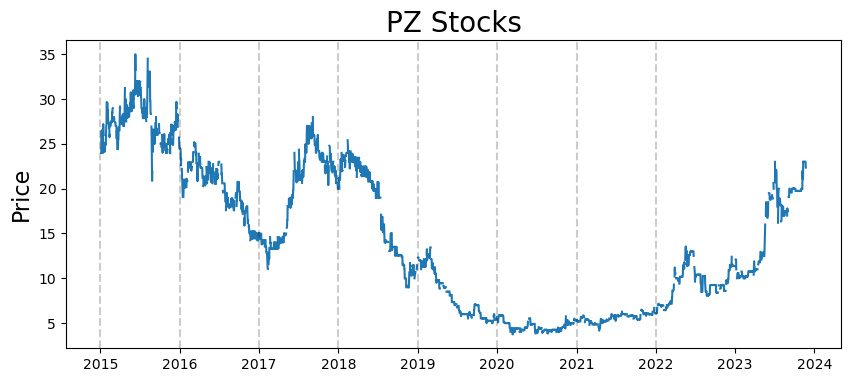

In [7]:
plt.figure(figsize=(10,4))
plt.plot(lim_df)
lim_df=lim_df.dropna()
plt.title('PZ Stocks', fontsize=20)
plt.ylabel('Price', fontsize=16)
for year in range(start_date.year,end_date.year):
    plt.axvline(pd.to_datetime(str(year)+'-01-01'), color='k', linestyle='--', alpha=0.2)

## Remove the trend

In [8]:
first_diff = df.diff()[1:]

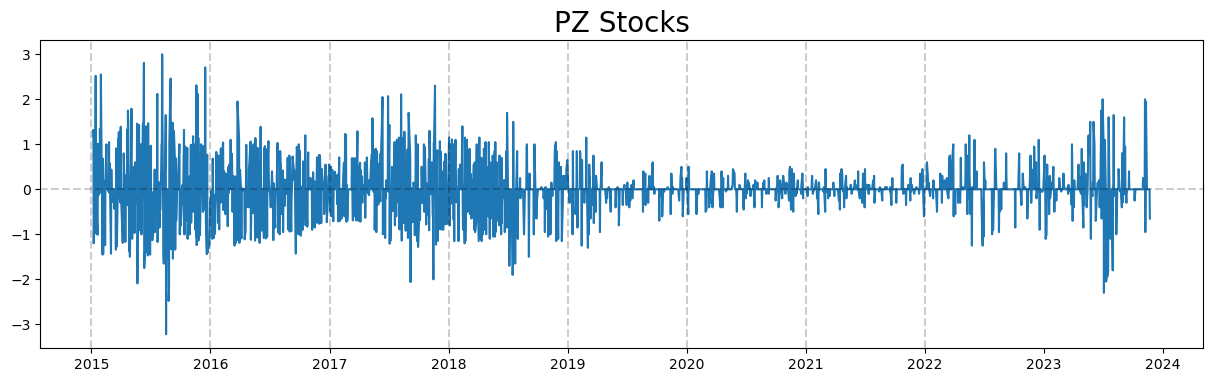

In [9]:
plt.figure(figsize=(15,4))
plt.plot(first_diff)
plt.title('PZ Stocks', fontsize=20)
plt.ylabel('', fontsize=16)
for year in range(start_date.year,end_date.year):
    plt.axvline(pd.to_datetime(str(year)+'-01-01'), color='k', linestyle='--', alpha=0.2)
plt.axhline(0, color='k', linestyle='--', alpha=0.2)

# ACF

<BarContainer object of 24 artists>

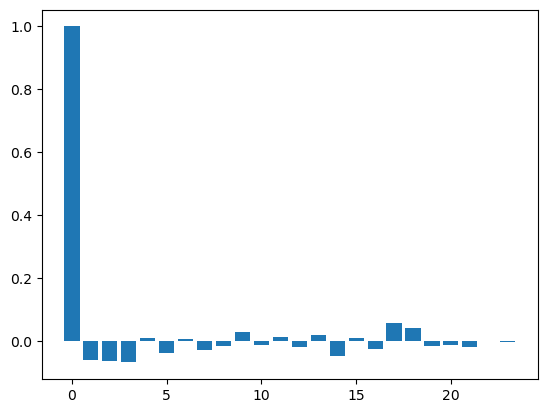

In [10]:
acf_vals = acf(first_diff)
num_lags = 24
plt.bar(range(num_lags), acf_vals[:num_lags])

# PACF

<BarContainer object of 24 artists>

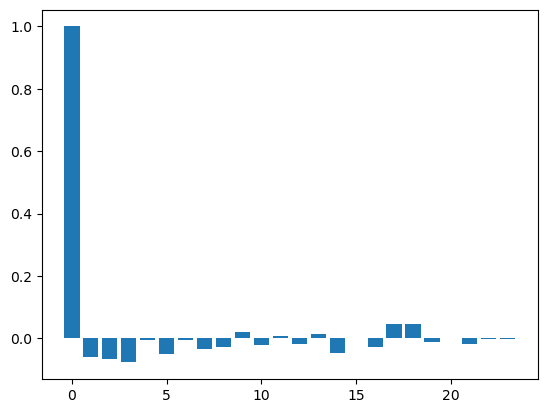

In [11]:
pacf_vals = pacf(first_diff)
num_lags = 24
plt.bar(range(num_lags), pacf_vals[:num_lags])

# Get training and testing sets

In [12]:
from statsmodels.tsa.stattools import adfuller

def adf_test(dataset):
  dftest = adfuller(dataset, autolag = 'AIC')
  print("1. ADF : ",dftest[0])
  print("2. P-Value : ", dftest[1])
  print("3. Num Of Lags : ", dftest[2])
  print("4. Num Of Observations Used For ADF Regression and Critical Values Calculation :", dftest[3])
  print("5. Critical Values :")
  for key, val in dftest[4].items():
      print("\t",key, ": ", val)


In [13]:
adf_test(df['Price'])

1. ADF :  -1.3799467278651478
2. P-Value :  0.5918512622553317
3. Num Of Lags :  5
4. Num Of Observations Used For ADF Regression and Critical Values Calculation : 2195
5. Critical Values :
	 1% :  -3.4333326714656223
	 5% :  -2.8628576479452597
	 10% :  -2.5674714486226202


In [30]:
train_end = datetime(2023,11,15)
test_end = datetime(2023,11,22)

train_data = lim_df[:train_end]
test_data = lim_df[train_end + timedelta(days=1):test_end]

# Fit the SARIMA Model

In [ ]:
train_data = train_data.dropna()
stepwise_model = auto_arima(train_data, start_p=1, start_q=1,
                           m=20,
                           start_P=0, start_Q=2, seasonal=True,
                           d=0, D=3, trace=True,
                           error_action='ignore',  
                           suppress_warnings=True, 
                           stepwise=True)

print(stepwise_model.aic())

C:\Users\USER\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\USER\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\USER\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'
C:\Users\USER\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\USER\anaconda3\Lib\site

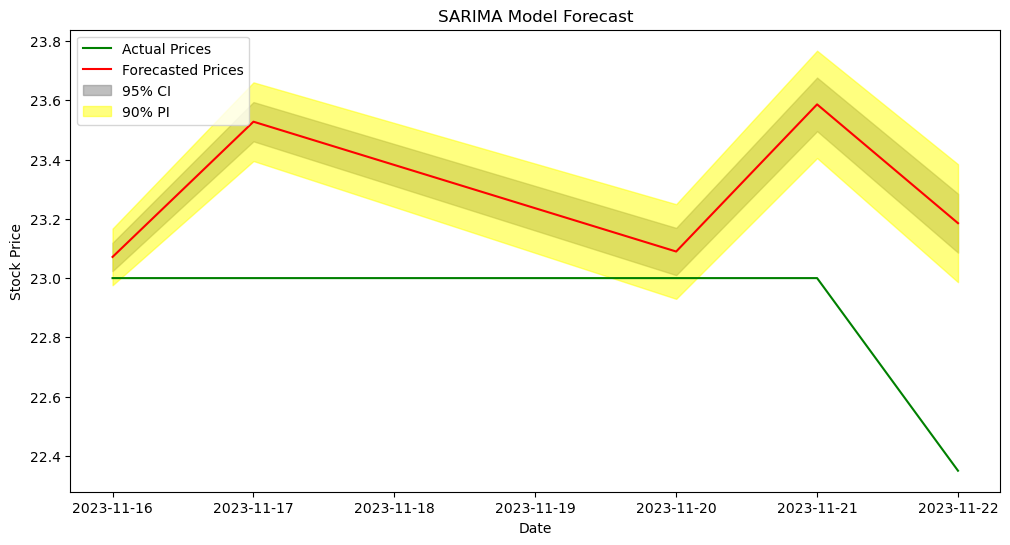

In [31]:
p = 1  # Order of autoregression (AR)
d = 0 # Degree of differencing (I)
q = 1  # Order of moving average (MA)
P = 0  # Seasonal order of autoregression (SAR)
D = 3  # Seasonal degree of differencing (SI)
Q = 2  # Seasonal order of moving average (SMA)
s = 20  # Seasonal period (e.g., 12 for monthly data)

sarima_model = sm.tsa.SARIMAX(train_data, order=(p, d, q), seasonal_order=(P, D, Q, s))
sarima_result = sarima_model.fit()
#summary of the model



# Forecast future values
forecast_periods = len(test_data)
sarima_forecast = sarima_result.get_forecast(steps=forecast_periods)

# Get the forecasted values, confidence intervals, and prediction intervals
forecast_mean = sarima_forecast.predicted_mean 
forecast_ci = sarima_forecast.conf_int(alpha=0.95)
forecast_pi = sarima_forecast.conf_int(alpha=0.9)  # 10% prediction intervals
forecast_mean.index = test_data.index
forecast_ci.index = test_data.index
forecast_pi.index = test_data.index
forecast_mean = forecast_mean.dropna()
test_data = test_data.dropna()

# Plot the actual vs. forecasted values
plt.figure(figsize=(12, 6))
#plt.plot(train_data.index, train_data['Price'], label='Training Data', color='blue')
plt.plot(test_data.index, test_data, label='Actual Prices', color='green')
plt.plot(forecast_mean.index, forecast_mean, label='Forecasted Prices', color='red')
plt.fill_between(forecast_ci.index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], color='grey', alpha=0.5, label='95% CI')
plt.fill_between(forecast_pi.index, forecast_pi.iloc[:, 0], forecast_pi.iloc[:, 1], color='yellow', alpha=0.5, label='90% PI')
plt.title('SARIMA Model Forecast')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.show()


In [ ]:
print(sarima_result.summary())

In [32]:
test_data = test_data.dropna()
forecast_mean = forecast_mean.dropna()
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
from math import sqrt
rmse=sqrt(mean_squared_error(forecast_mean,test_data))
mae=mean_absolute_percentage_error(forecast_mean,test_data)
print('Root Mean Squared Error:',rmse)
print('Mean Absolute Percentage Error:',mae)

Root Mean Squared Error: 0.5163691330469949
Mean Absolute Percentage Error: 0.01805997437261322


In [ ]:
index_future_dates=pd.date_range(start='2023-11-23',end='2023-12-8')
pred=sarima_result.predict(start=len(df),end=len(df)+15,typ='levels').rename('SARIMA Predictions')
pred.index=index_future_dates
print(pred)
pred.plot()

In [ ]:
print(pred)

In [ ]:
#get the predictions and residuals
predictions = model_fit.get_prediction(len(test_data))
predictions = pd.Series(forecast_mean, index=forecast_mean.index)
residuals = test_data - predictions

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(residuals)
plt.axhline(0, linestyle='--', color='k')
plt.title('Residuals from SARIMA Model', fontsize=20)
plt.ylabel('Error', fontsize=16)

In [ ]:
plt.figure(figsize=(10,4))

plt.plot(lim_df)
plt.plot(predictions)

plt.legend(('Data', 'Predictions'), fontsize=16)

plt.title('PZ Data', fontsize=20)
plt.ylabel('Price', fontsize=16)
for year in range(start_date.year,end_date.year):
    plt.axvline(pd.to_datetime(str(year)+'-01-01'), color='k', linestyle='--', alpha=0.1)

In [ ]:
print('Mean Absolute Percent Error:', round(np.mean(abs(residuals/test_data)),4))

In [ ]:
print('Root Mean Squared Error:', np.sqrt(np.mean(residuals**2)))

# Using the Rolling Forecast Origin

In [ ]:
rolling_predictions = test_data.copy()
for train_end in test_data.index:
    train_data = lim_df[:train_end-timedelta(days=1)]
    model = SARIMAX(train_data, order=(1,1,1), seasonal_order=(0,3,1,10))
    model_fit = model.fit()

    pred = model_fit.forecast()
    rolling_predictions[train_end] = pred

In [ ]:
rolling_residuals = test_data - rolling_predictions

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(rolling_residuals)
plt.axhline(0, linestyle='--', color='k')
plt.title('Rolling Forecast Residuals from SARIMA Model', fontsize=20)
plt.ylabel('Error', fontsize=16)

In [ ]:
plt.figure(figsize=(10,4))

plt.plot(lim_df)
plt.plot(rolling_predictions)

plt.legend(('Data', 'Predictions'), fontsize=16)

plt.title('PZ Data', fontsize=20)
plt.ylabel('Price', fontsize=16)
for year in range(start_date.year,end_date.year):
    plt.axvline(pd.to_datetime(str(year)+'-01-01'), color='k', linestyle='--', alpha=0.2)

In [ ]:
print('Mean Absolute Percent Error:', round(np.mean(abs(rolling_residuals/test_data)),4))

In [ ]:
print('Root Mean Squared Error:', np.sqrt(np.mean(rolling_residuals**2)))